---
## Setup

In [ ]:
import os
import tensorflow as tf
os.environ['TFHUB_MODEL_LOAD_FORMAT'] = 'COMPRESSED'

import IPython.display as display

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (12,12)
mpl.rcParams['axes.grid'] = False

import numpy as np
import time
import PIL.Image
import functools

from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

In [ ]:
# Image Credits: Tensorflow Doc
content_path = tf.keras.utils.get_file(
  'content.jpg',
  'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
style_path = tf.keras.utils.get_file(
  'style.jpg',
  'https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
195196/195196 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def load_and_process_image(image_path):
    img = load_img(image_path, target_size=(328, 500))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = tf.image.resize(img, (328, 500))

    img = tf.expand_dims(img, axis=0)

    return tf.cast(img, tf.float32)


def deprocess(img):
    img = img.copy()

    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68

    img = img[:, :, ::-1]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img


---
## Preprocess

In [ ]:
def display_image(image):
    if len(image.shape) == 4:
        img = np.squeeze(image, axis=0)

    img = deprocess(img)

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)
    plt.show()


def display_image(image):
    if len(image.shape) == 4:
        img = np.squeeze(image, axis=0)

    img = deprocess(img)

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)
    return

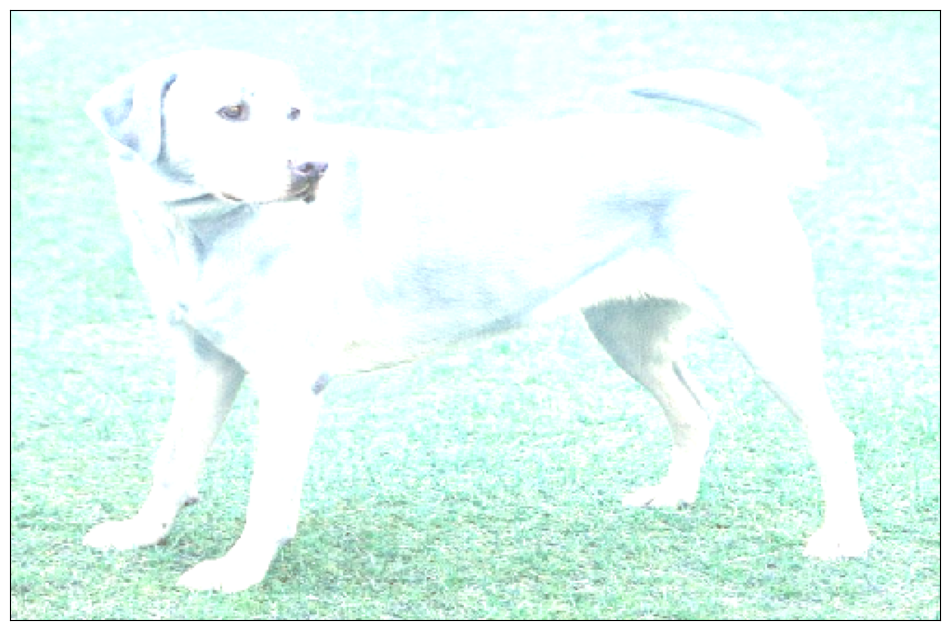

In [ ]:
content_img = load_and_process_image(content_path)
display_image(content_img)

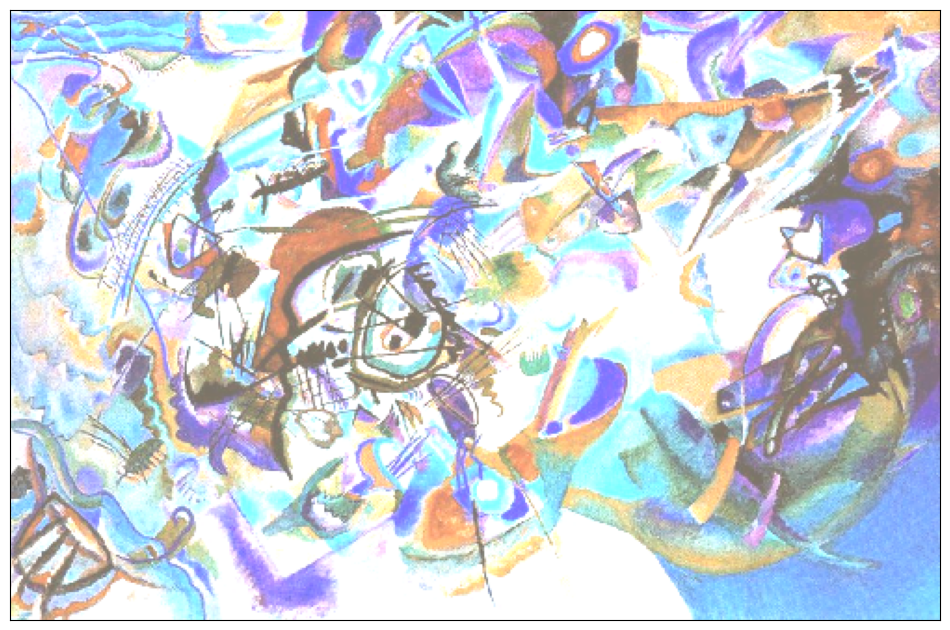

In [ ]:
style_img = load_and_process_image(style_path)
display_image(style_img)

In [ ]:
model = EfficientNetB0(
    include_top = False,
    weights = 'imagenet'
)
model.trainable = False
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
content_layer = 'block6d_activation'
content_model = Model(inputs = model.input,
                      outputs = model.get_layer(content_layer).output)

content_model.summary()

style_layers = [
    'stem_activation',
    'block2a_activation',
    'block3a_activation',
    'block4a_activation',
    'block5a_activation'
]

style_models = [Model(inputs=model.input,
                      outputs=model.get_layer(layer).output)for layer in style_layers]

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 2,578,627 (9.84 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,578,627 (9.84 MB)

In [ ]:
def content_loss(content, generated):
    a_C = content_model(content)
    a_G = content_model(generated)
    loss = tf.reduce_mean(tf.square(a_C - a_G))
    return loss
def gram_matrix(A):
    channels = int(A.shape[-1])
    a = tf.reshape(A, [-1, channels])
    n = tf.shape(a)[0]
    gram = tf.matmul(a,a,transpose_a = True)
    return gram/tf.cast(n, tf.float32)

weight_of_layer =  1./len(style_layers)

def style_cost(style, generated):
    J_style = 0

    for style_model in style_models:
        a_style = style_model(style)
        a_generated = style_model(generated)
        gram_a_style = gram_matrix(a_style)
        gram_a_generated = gram_matrix(a_generated)
        content_cost = tf.reduce_mean(tf.square(gram_a_generated - gram_a_style ))
        J_style += content_cost + weight_of_layer # bisa di ganti pake "*" instead of "+"

    return J_style

def content_cost(style, generated):
    J_content = 0

    for style_model in style_models:
        a_style = style_model(style)
        a_generated = style_model(generated)
        gram_a_style = gram_matrix(a_style)
        gram_a_generated = gram_matrix(a_generated)
        content_cost = tf.reduce_mean(tf.square(gram_a_style - gram_a_generated))
        J_content += content_cost + weight_of_layer # bisa di ganti pake "*" instead of "+"

    return J_content

In [ ]:
import os
import tensorflow as tf
import numpy as np
import time
import math

generated_images = []

def save_checkpoint(generated, iteration, path="checkpoint.npz"):
    np.savez(path, generated=generated.numpy(), iteration=iteration)

def load_checkpoint(path="checkpoint.npz"):
    data = np.load(path)
    return tf.Variable(data["generated"], dtype=tf.float32), int(data["iteration"])

def training_loop(content_path, style_path, iterations=1500, start_iter=0, a=10, b=1000, checkpoint_path="checkpoint.npz"):
    content = load_and_process_image(content_path)
    style = load_and_process_image(style_path)

    # Load previous checkpoint if available
    if start_iter > 0 and os.path.exists(checkpoint_path):
        generated, start_iter = load_checkpoint(checkpoint_path)
        print(f"Resuming from iteration {start_iter}")
    else:
        generated = tf.Variable(content, dtype=tf.float32)

    opt = tf.keras.optimizers.Adam(learning_rate=0.7)
    best_cost = math.inf
    best_image = None

    for i in range(start_iter + 1, start_iter + iterations + 1):
        start_time_cpu = time.process_time()
        start_time_wall = time.time()

        with tf.GradientTape() as tape:
            J_content = content_cost(content, generated)
            J_style = style_cost(style, generated)
            J_total = a * J_content + b * J_style

        grads = tape.gradient(J_total, generated)
        opt.apply_gradients([(grads, generated)])

        end_time_cpu = time.process_time()
        end_time_wall = time.time()
        cpu_time = end_time_cpu - start_time_cpu
        wall_time = end_time_wall - start_time_wall

        if J_total < best_cost:
            best_cost = J_total
            best_image = generated.numpy()

        print(f"Iteration: {i}")
        print(f"CPU Time: {cpu_time * 1e6:.2f} µs, Wall Time: {wall_time * 1e6:.2f} µs")
        print(f"Total Loss: {J_total:.4e}")

        if i % 300 == 0:
            print(f"Saving checkpoint at iteration {i}")
            generated_images.append(generated.numpy())
            save_checkpoint(generated, i, path=checkpoint_path)

    return best_image

In [ ]:
final_image = training_loop(content_path, style_path)

In [ ]:
# Deprocess dulu biar bisa ditampilin
def deprocess(img):
    img = img.copy()  # supaya gak error read-only
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]  # BGR ke RGB
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def display_image(img_array):
    if len(img_array.shape) == 4:
        img_array = np.squeeze(img_array, axis=0)
    img = deprocess(img_array)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


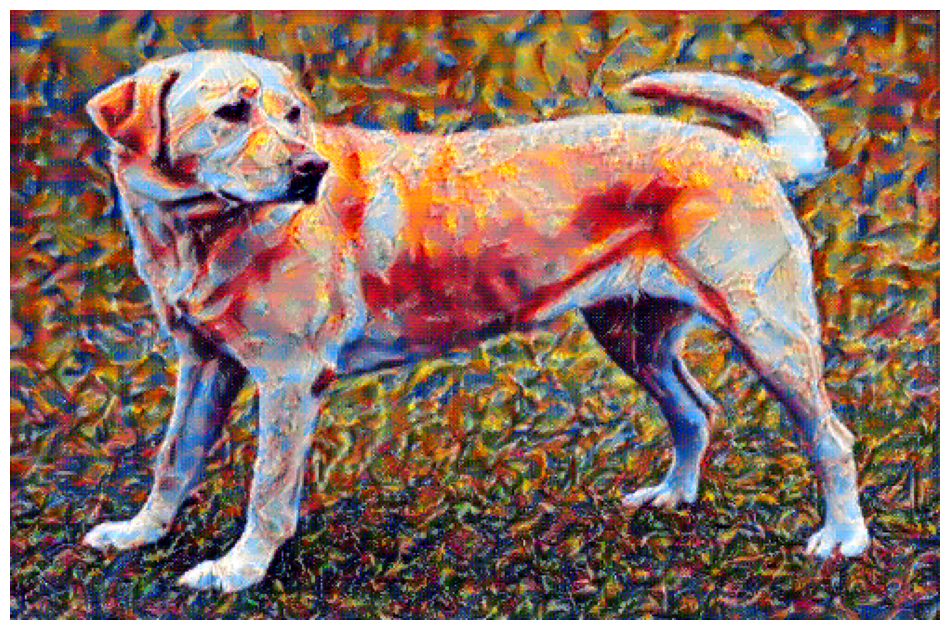

In [ ]:
last_generated = generated_images[-1]

# Ayo kita lihat hasil terakhir
display_image(last_generated)


In [ ]:
content_path_new = "/content/someLogo.jpg"

In [ ]:
final_image_new = training_loop(content_path_new, style_path)

Iteration: 1
CPU Time: 4706017.09 µs, Wall Time: 6909224.27 µs
Total Loss: 7.0485e+05
Iteration: 2
CPU Time: 3266487.98 µs, Wall Time: 3712020.64 µs
Total Loss: 6.7713e+05
Iteration: 3
CPU Time: 2876855.24 µs, Wall Time: 2883501.29 µs
Total Loss: 6.4873e+05
Iteration: 4
CPU Time: 3074837.18 µs, Wall Time: 3114034.89 µs
Total Loss: 6.2241e+05
Iteration: 5
CPU Time: 2679691.30 µs, Wall Time: 2670977.83 µs
Total Loss: 5.9897e+05
Iteration: 6
CPU Time: 2643930.82 µs, Wall Time: 2634739.88 µs
Total Loss: 5.7821e+05
Iteration: 7
CPU Time: 2645615.11 µs, Wall Time: 2638855.70 µs
Total Loss: 5.5985e+05
Iteration: 8
CPU Time: 3241950.14 µs, Wall Time: 3292248.96 µs
Total Loss: 5.4354e+05
Iteration: 9
CPU Time: 2625444.78 µs, Wall Time: 2620115.52 µs
Total Loss: 5.2894e+05
Iteration: 10
CPU Time: 2659415.83 µs, Wall Time: 2654003.38 µs
Total Loss: 5.1576e+05
Iteration: 11
CPU Time: 2660643.25 µs, Wall Time: 2657965.66 µs
Total Loss: 5.0370e+05
Iteration: 12
CPU Time: 3297203.29 µs, Wall Time: 33

In [ ]:
# Tampilkan dengan matplotlib
import matplotlib.pyplot as plt

def display_image(img_array):
    if len(img_array.shape) == 4:
        img_array = np.squeeze(img_array, axis=0)
    img = deprocess(img_array)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


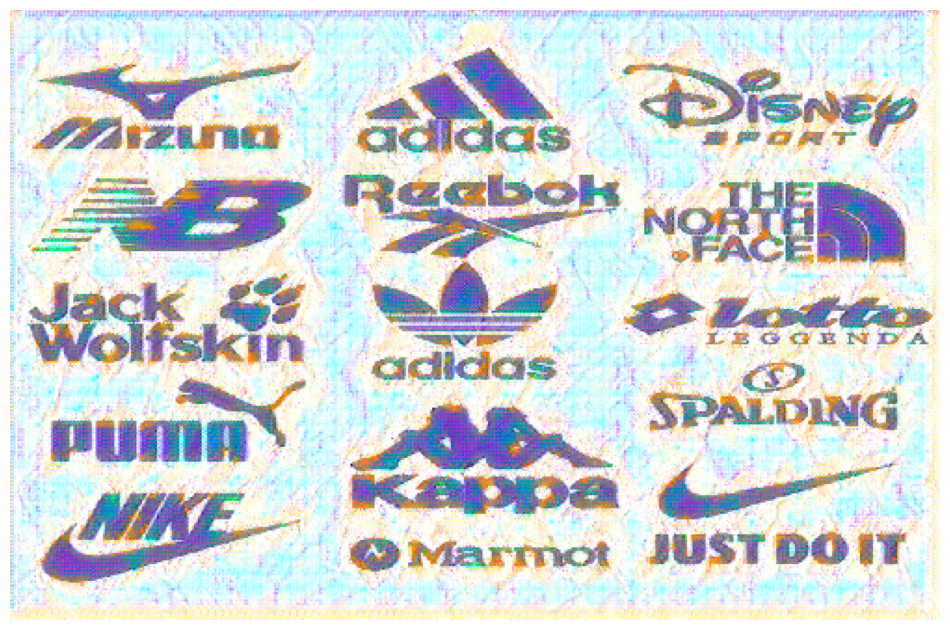

In [ ]:
last_generated = generated_images[-1]

# Ayo kita lihat hasil terakhir
display_image(last_generated)
